# Dimensionality Reduction: PCA & t-SNE untuk Segmentasi Pelanggan Kartu Kredit
Tugas Kelompok - P17 Anggota Kelompok:

1.   Muhammad Fadhil Aprilino (24523175)
2.   Pradipta Pramatya Panhar (24523052)

Dataset: perilaku penggunaan kartu kredit dari sekitar 8.950 pelanggan aktif selama 6 bulan terakhir (CC_GENERAL.csv)

Sumber: kaggle (https://www.kaggle.com/datasets/arjunbhasin2013/ccdata) (Kaggle, by arjunbhasin2013)

Deskripsi: Kasus penggunaan yang diangkat adalah eksplorasi cluster untuk segmentasi pelanggan.

Perusahaan kartu kredit ingin mengetahui ada berapa "tipe" pelanggan berdasarkan pola penggunaan kartu mereka (saldo, jumlah belanja, penggunaan cash advance, dll), agar dapat memberikan strategi marketing/penawaran yang sesuai untuk tiap tipe pelanggan.

Dataset ini memiliki 17 fitur perilaku per pelanggan, yang mustahil dilihat pola pengelompokannya secara langsung.

Dimensionality reduction dibutuhkan untuk meringkas 17 fitur ini menjadi 2 dimensi yang bisa divisualisasikan, sehingga pola/cluster pelanggan bisa terlihat dan diinterpretasikan.




## 1. Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


## 2. Load & Eksplorasi Dataset

In [2]:
df = pd.read_csv('CC_GENERAL.csv')

print("Jumlah pelanggan:", df.shape[0])
print("Jumlah fitur asli:", df.shape[1])
df.head()


Jumlah pelanggan: 8950
Jumlah fitur asli: 18


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

## 3. Data Cleaning

In [4]:
# CUST_ID hanya identifier, bukan fitur perilaku jadi dibuang
df_clean = df.drop(columns=['CUST_ID'])

# Cek missing values
print("Missing values sebelum cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Isi missing value dengan median (robust terhadap outlier)
df_clean['MINIMUM_PAYMENTS'] = df_clean['MINIMUM_PAYMENTS'].fillna(df_clean['MINIMUM_PAYMENTS'].median())
df_clean['CREDIT_LIMIT'] = df_clean['CREDIT_LIMIT'].fillna(df_clean['CREDIT_LIMIT'].median())

print("\nMissing values setelah cleaning:", df_clean.isnull().sum().sum())
print("Shape akhir:", df_clean.shape)


Missing values sebelum cleaning:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Missing values setelah cleaning: 0
Shape akhir: (8950, 17)


## 4. Standardisasi & Clustering Awal (KMeans)

### Sebelum PCA/t-SNE
 dilakukan standardisasi karena kedua metode sensitif terhadap skala fitur. Untuk membantu interpretasi visualisasi,dan dilakukan clustering awal dengan **KMeans (k=4)** pada data yang sudah distandardisasi, supaya hasil PCA & t-SNE bisa diwarnai berdasarkan cluster pelanggan yang terbentuk.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_clean['Cluster'] = clusters
print("Jumlah pelanggan per cluster:")
print(df_clean['Cluster'].value_counts().sort_index())

Jumlah pelanggan per cluster:
Cluster
0    3977
1     409
2    1197
3    3367
Name: count, dtype: int64


In [6]:
# Karakteristik rata-rata tiap cluster
summary = df_clean.groupby('Cluster')[['BALANCE','PURCHASES','CASH_ADVANCE','CREDIT_LIMIT','PAYMENTS','PRC_FULL_PAYMENT']].mean().round(1)
summary

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
Cluster,,,,,,
0,1012.7,270.0,596.5,3278.6,974.3,0.1
1,3551.2,7681.6,653.6,9696.9,7288.7,0.3
2,4602.4,501.9,4521.5,7546.2,3484.1,0.0
3,894.9,1236.2,210.6,4213.2,1332.2,0.3


| Cluster | Jumlah Pelanggan | Karakteristik |
|---|---|---|
| 0 | 3.977 | Saldo & belanja rendah, limit kecil → **pelanggan pasif** |
| 1 | 409 | Saldo & belanja tertinggi, cukup sering bayar penuh → **pelanggan premium / big spender** |
| 2 | 1.197 | Cash advance sangat tinggi, jarang bayar penuh → **pengguna cash advance (revolver)** |
| 3 | 3.367 | Belanja moderat, disiplin bayar penuh → **pelanggan sehat & disiplin** |

## 5. Implementasi PCA

In [8]:
# Reduksi ke 2 dimensi
X_features = X_scaled  # hasil standardisasi 17 fitur (tanpa kolom Cluster)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_features)

explained_variance = pca.explained_variance_ratio_
print(f"Explained variance PC1 & PC2: {explained_variance}")
print(f"Total explained variance: {sum(explained_variance):.2%}")
print(f"\nShape sebelum: {X_features.shape} -> sesudah: {X_pca.shape}")


Explained variance PC1 & PC2: [0.27297671 0.2031378 ]
Total explained variance: 47.61%

Shape sebelum: (8950, 17) -> sesudah: (8950, 2)


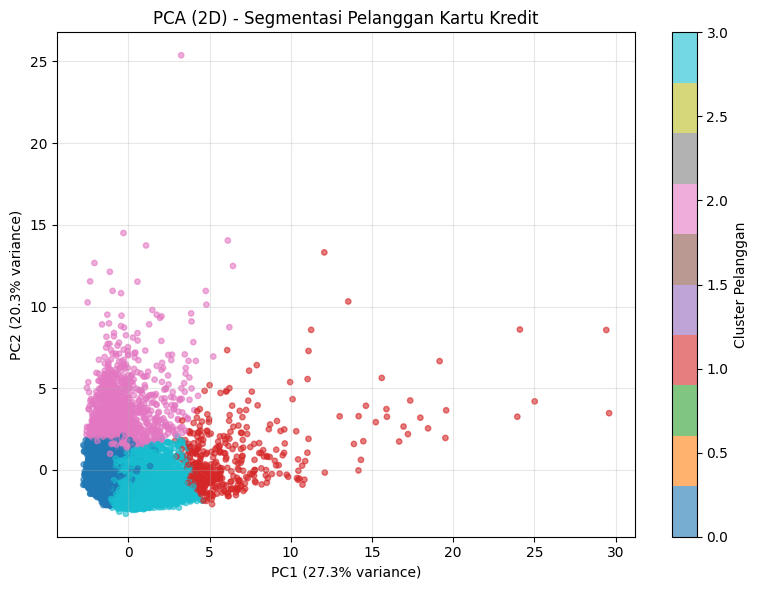

In [9]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='tab10', alpha=0.6, s=15)
plt.colorbar(scatter, label='Cluster Pelanggan')
plt.xlabel(f'PC1 ({explained_variance[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_variance[1]*100:.1f}% variance)')
plt.title('PCA (2D) - Segmentasi Pelanggan Kartu Kredit')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretasi PCA
 PC1 dan PC2 bersama-sama menangkap sekitar 47,6% variansi data (PC1 ≈ 27,3%, PC2 ≈ 20,3%) karena fitur-fitur perilaku finansial ini banyak yang berkorelasi linear satu sama lain (misalnya balance berkorelasi dengan credit limit). Dari plot terlihat cluster 1 (pelanggan premium) berada jelas terpisah di salah satu sisi, sedangkan cluster 0 dan 3 (pelanggan pasif dan disiplin) cenderung tumpang tindih karena keduanya sama-sama memiliki saldo yang relatif rendah.

## 6. Implementasi t-SNE

In [10]:
n_samples = 1000
np.random.seed(42)
idx = np.random.choice(len(X_features), n_samples, replace=False)
X_sub = X_features[idx]
clusters_sub = clusters[idx]

tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_sub)

print(f"Shape sebelum: {X_sub.shape} -> sesudah: {X_tsne.shape}")


Shape sebelum: (1000, 17) -> sesudah: (1000, 2)


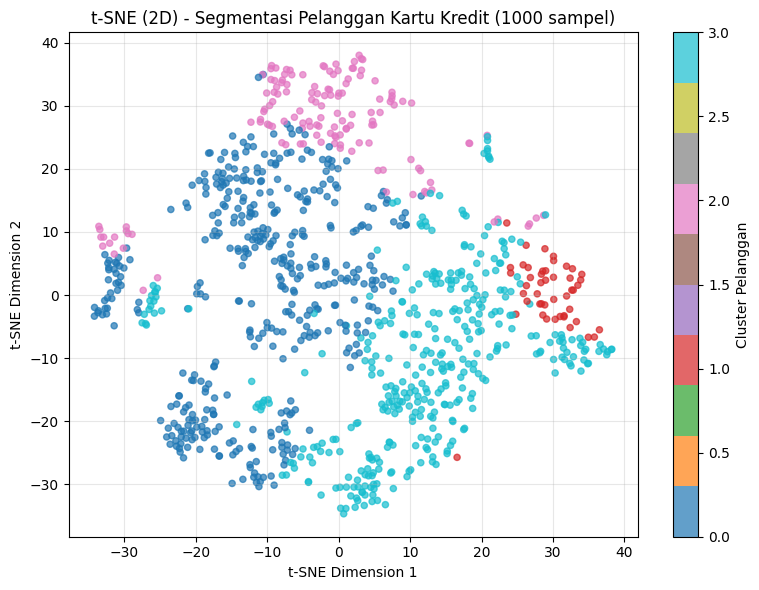

In [11]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_sub, cmap='tab10', alpha=0.7, s=20)
plt.colorbar(scatter, label='Cluster Pelanggan')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE (2D) - Segmentasi Pelanggan Kartu Kredit (1000 sampel)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Interpretasi t-SNE
 Dibandingkan PCA, hasil t-SNE menunjukkan pemisahan antar cluster yang jauh lebih rapi. Kelompok pelanggan revolver (cash advance tinggi) dan pelanggan premium (big spender) terlihat membentuk kelompok yang cukup terpisah dari kelompok pelanggan pasif/disiplin, karena t-SNE mampu menangkap hubungan non-linear antar fitur perilaku yang tidak tertangkap oleh PCA.

# 7. Analisis: PCA vs t-SNE


### Perbedaan hasil:
- PCA berhasil menangkap sekitar 47,6% variansi data dalam 2 dimensi, namun beberapa cluster (khususnya pelanggan pasif dan disiplin) masih tumpang tindih karena PCA hanya menangkap hubungan linear.
- t-SNE menghasilkan pemisahan cluster yang lebih jelas, karena mempertahankan hubungan tetangga terdekat secara non-linear.
- PCA jauh lebih cepat secara komputasi dan komponennya memiliki makna matematis yang jelas (arah variansi terbesar), sementara t-SNE lebih lambat dan jarak antar cluster tidak selalu bermakna literal.



### Metode mana yang lebih sesuai untuk kasus ini:

Untuk kasus **eksplorasi cluster pelanggan**, **t-SNE lebih sesuai** karena mampu menunjukkan pemisahan segmen pelanggan yang lebih jelas, sehingga tim marketing bisa lebih yakin dalam menentukan strategi per segmen. Namun demikian, PCA tetap berguna sebagai langkah awal yang cepat, misalnya untuk mereduksi noise/redundansi fitur sebelum clustering dijalankan, karena beberapa fitur asli (seperti BALANCE dan CREDIT_LIMIT) memang saling berkorelasi tinggi.



## 8. Kesimpulan

### Dimensionality reduction (PCA & t-SNE)
terbukti membantu memvisualisasikan pola segmentasi pelanggan kartu kredit yang awalnya tersebar dalam 17 fitur berdimensi tinggi. Ditemukan 4 segmen pelanggan yang berbeda karakteristik: pelanggan pasif, pelanggan premium/big spender, pengguna cash advance (revolver), dan pelanggan sehat & disiplin bayar. Insight ini dapat digunakan perusahaan kartu kredit untuk merancang strategi marketing yang berbeda-beda sesuai segmen, misalnya program cicilan untuk revolver atau reward eksklusif untuk pelanggan premium.